In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score
pd.set_option("display.max_columns", None)

In [2]:
df=pd.read_csv('datos_limpios.csv')
df.head(3)

,ASSETID,PERIOD,PRICE,UNITPRICE,CONSTRUCTEDAREA,ROOMNUMBER,BATHNUMBER,HASTERRACE,HASLIFT,HASAIRCONDITIONING,AMENITYID,HASPARKINGSPACE,ISPARKINGSPACEINCLUDEDINPRICE,HASNORTHORIENTATION,HASSOUTHORIENTATION,HASEASTORIENTATION,HASWESTORIENTATION,HASBOXROOM,HASWARDROBE,HASSWIMMINGPOOL,HASDOORMAN,HASGARDEN,ISDUPLEX,ISSTUDIO,ISINTOPFLOOR,FLOORCLEAN,FLATLOCATIONID,CADCONSTRUCTIONYEAR,CADMAXBUILDINGFLOOR,CADDWELLINGCOUNT,CADASTRALQUALITYID,DISTANCE_TO_CITY_CENTER,DISTANCE_TO_METRO,DISTANCE_TO_STREET,LONGITUDE,LATITUDE,CITYNAME,BUILTTYPEID,LOG_PRICE,LOG_CONSTRUCTEDAREA
0,A12377633511549727658,201812,109000,1730.158730,63,3,1,True,False,False,3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,3.0,1.0,1965,5,22,7.0,4.166611,0.313529,2.814425,-3.726785,40.383510,Madrid,3,11.599112,4.158883
1,A7691539882862170545,201809,155000,2384.615385,65,2,1,False,True,True,3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,4.0,1.0,1967,6,79,6.0,4.477237,0.109565,2.934052,-3.726764,40.380375,Madrid,3,11.951187,4.189655
2,A4316988685482817826,201809,158000,2025.641026,78,3,1,True,True,True,3,False,False,False,True,True,True,False,True,False,False,False,False,False,False,2.0,1.0,1955,4,15,6.0,4.294954,0.217547,2.788894,-3.725683,40.381796,Madrid,3,11.970357,4.369448


In [3]:
correlaciones=df.corr(numeric_only=True).round(2)

<Axes: xlabel='CADCONSTRUCTIONYEAR', ylabel='Count'>

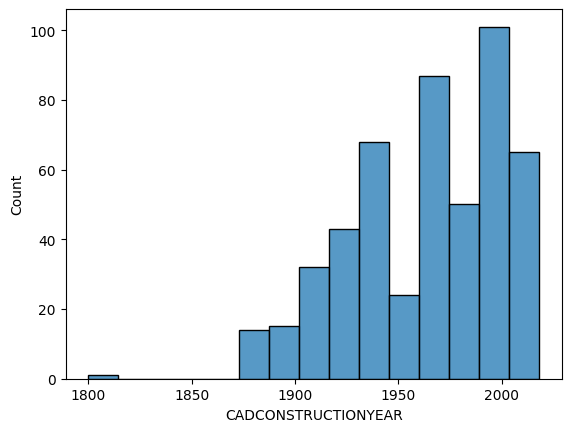

In [4]:
sns.histplot(
    x='CADCONSTRUCTIONYEAR',
    data=df[df['CADASTRALQUALITYID']==0]
)

<Axes: xlabel='CADASTRALQUALITYID', ylabel='UNITPRICE'>

c:\Users\User\Bootcamp\Proyecto\.venv\Lib\site-packages\IPython\core\events.py:100: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
c:\Users\User\Bootcamp\Proyecto\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


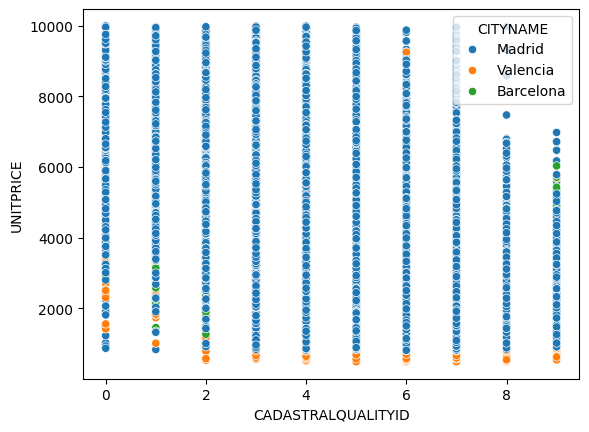

In [6]:
sns.scatterplot(
    x='CADASTRALQUALITYID',
    y='UNITPRICE',
    hue='CITYNAME',
    data=df
)

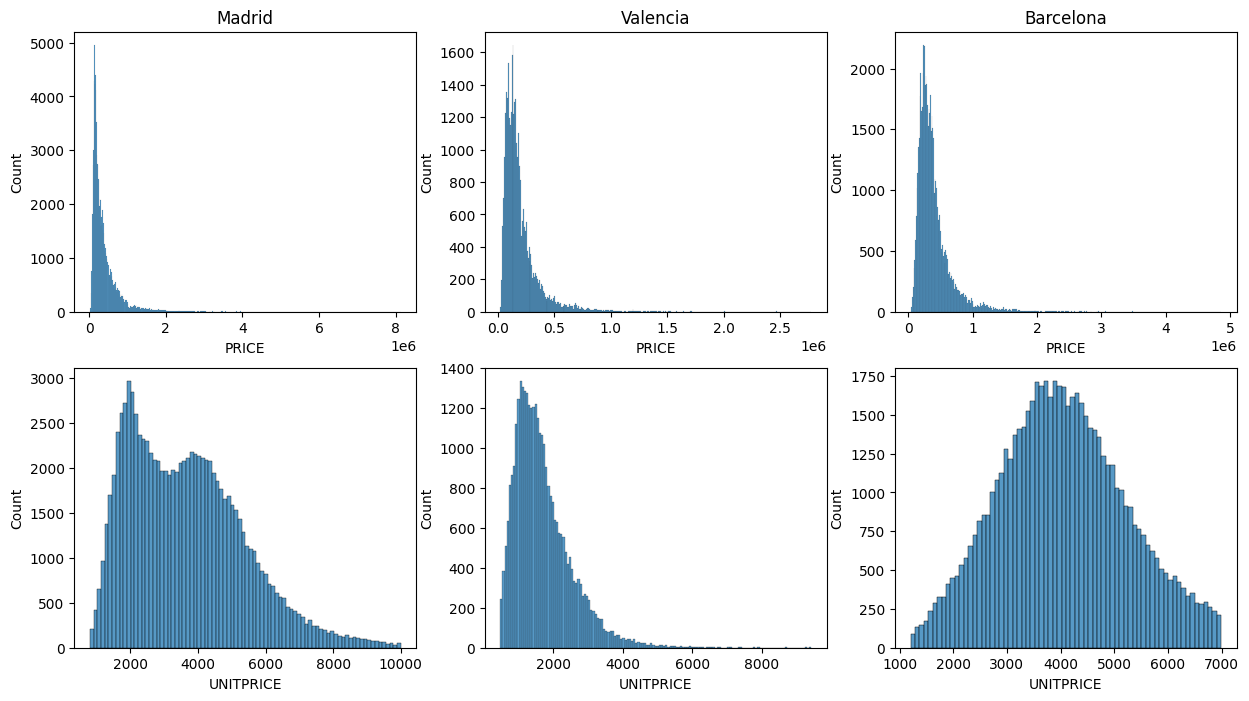

In [8]:
ciudades=df['CITYNAME'].unique()
columnas=['PRICE','UNITPRICE']
plt.figure(figsize=(15,8))
for i,ciudad in enumerate(ciudades):
    for j,columna in enumerate(columnas):
        plt.subplot(2,len(ciudades),i+(1+j*len(ciudades)))
        dfciudad=df[df['CITYNAME']==ciudad]
        sns.histplot(
            x=columna,
            log_scale=False,
            data=dfciudad
        )
        if (j==0):
            plt.title(ciudad)
plt.show()
# unitprice es más normal que price, pero en escala logarítmica price es más normal que unitprice

In [9]:
for ciudad in ciudades:
    statistic,pvalue=stats.shapiro(df[df['CITYNAME']==ciudad].sample(1000)['UNITPRICE'])
    print(f"{ciudad}: {statistic} {pvalue} Normal={pvalue>0.05}")

Madrid: 0.9567913005407278 1.3636591971019632e-16 Normal=False
Valencia: 0.8819663544606179 6.7762742185969e-27 Normal=False
Barcelona: 0.9932318183755493 0.0001628178379973247 Normal=False


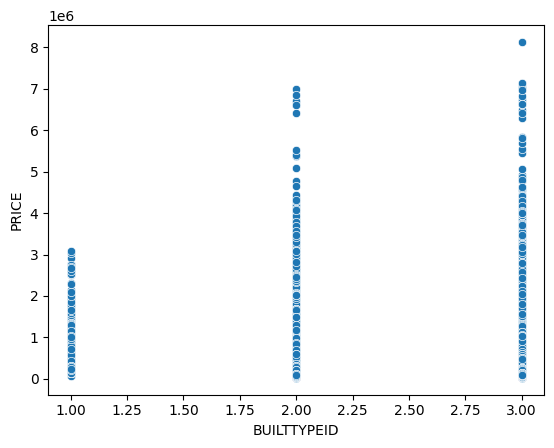

In [11]:
sns.scatterplot(
    x='BUILTTYPEID',
    y='PRICE',
    data=df
)
plt.show()
#los pisos de tipo 3 llegan a precios más altos que los de tipo 1, los de tipo dos están en un nivel intermedio

<Axes: xlabel='CONSTRUCTEDAREA', ylabel='PRICE'>

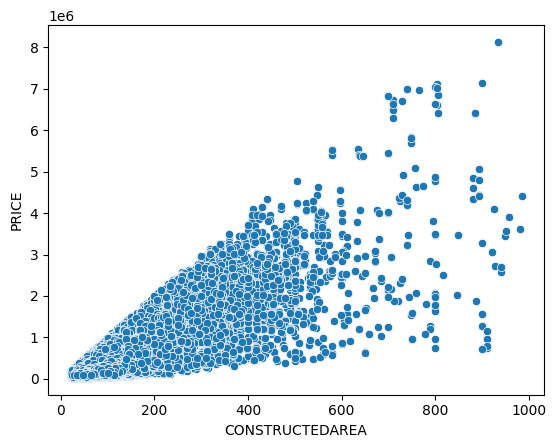

In [12]:
sns.scatterplot(
    x='CONSTRUCTEDAREA',
    y='PRICE',
    data=df
)

In [15]:
x:pd.DataFrame=df[['LOG_CONSTRUCTEDAREA']]
y:pd.Series=df['LOG_PRICE']

In [16]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.15,random_state=42)

In [17]:
model:LinearRegression=LinearRegression()
model.fit(x_train,y_train)
yhat=model.predict(x_test)
print(f"MAE: {mean_absolute_error(y_test,yhat)}")
print(f"MSE: {mean_squared_error(y_test,yhat)}")
print(f"RMSE: {root_mean_squared_error(y_test,yhat)}")
print(f"R2: {r2_score(y_test,yhat)}")

MAE: 0.44267337470439133
MSE: 0.29259079487222656
RMSE: 0.540916624695735
R2: 0.46186381015780265


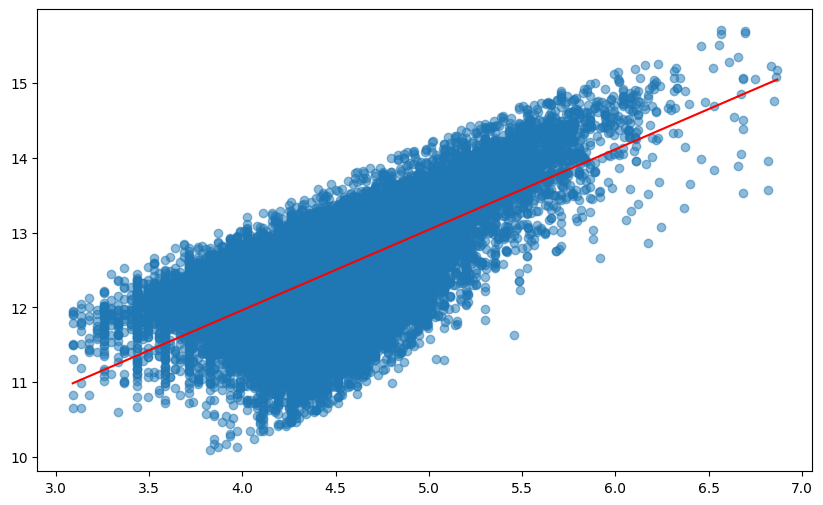

In [18]:
orden=x_test.iloc[:,0].argsort()
x_test_sorted=x_test.iloc[orden]
yhat_sorted=yhat[orden]
plt.figure(figsize=(10,6))
plt.scatter(x_test,y_test,alpha=0.5)
plt.plot(x_test_sorted,yhat_sorted,color='red')
plt.show()

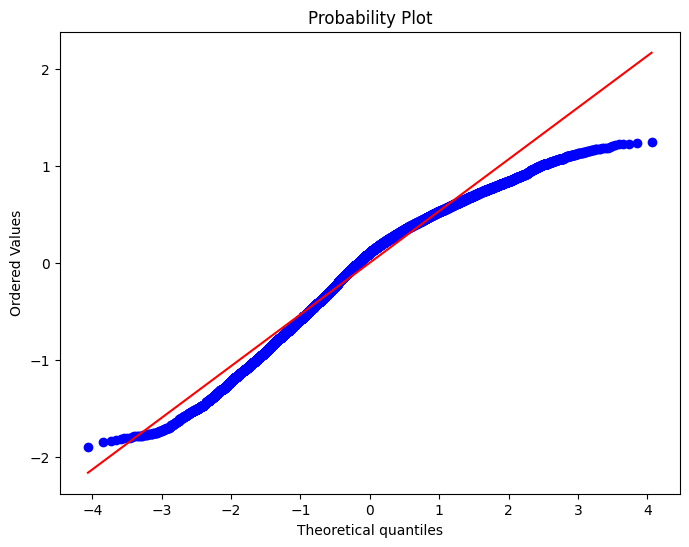

In [19]:
residuals=y_test-yhat
plt.figure(figsize=(8,6))
stats.probplot(residuals,dist='norm',plot=plt)
plt.show()
#tiene sesgo

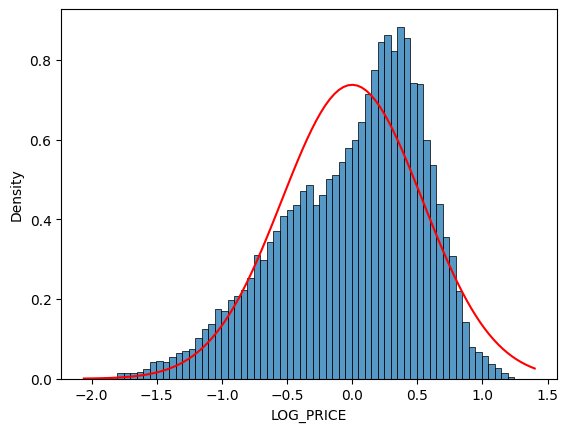

In [20]:
sns.histplot(
    x=residuals,
    stat='density',
)
media,std=np.mean(residuals),np.std(residuals)
xmin,xmax=plt.xlim()
x_teo=np.linspace(xmin,xmax,100)
y_teo=stats.norm.pdf(x_teo,media,std)
plt.plot(
    x_teo,y_teo,color='red'
)
plt.show()

In [21]:
residuals_z=(residuals-media)/std
print(stats.kstest(residuals_z,'norm'))
# los errores no son normales

KstestResult(statistic=np.float64(0.0772803677330326), pvalue=np.float64(1.986877447430727e-148), statistic_location=np.float64(0.24873799981523473), statistic_sign=np.int8(-1))


In [22]:
#Analisis estadistico del efecto de tener ascensor en el precio
con_ascensor=df[df["HASLIFT"]==True]["LOG_PRICE"]
sin_ascensor=df[df["HASLIFT"]==False]["LOG_PRICE"]

alpha=0.05
con_ascensor_z = ( con_ascensor- con_ascensor.mean()) / con_ascensor.std()

stat_n, p_n = stats.kstest(con_ascensor_z, "norm")

print(f"Estadístico: {stat_n}")
print(f"p-value: {p_n} | Normal: {p_n > alpha}")

sin_ascensor_z = ( sin_ascensor- sin_ascensor.mean()) / sin_ascensor.std()

stat_n, p_n = stats.kstest(sin_ascensor_z, "norm")

print(f"Estadístico: {stat_n}")
print(f"p-value: {p_n} | Normal: {p_n > alpha}")


stat_var, p_var = stats.levene(con_ascensor, sin_ascensor)

print(f"Estadístico: {stat_var}")
print(f"p-value: {p_var} | Varianzas diferentes: {p_var < alpha}")


print(con_ascensor.std()**2)
print(sin_ascensor.std()**2)

Estadístico: 0.027469556344784984
p-value: 5.043079717724549e-91 | Normal: False
Estadístico: 0.045232738060083655
p-value: 2.0926323862508196e-92 | Normal: False
Estadístico: 1016.4568017162004
p-value: 1.8488025794927242e-222 | Varianzas diferentes: True
0.47912988065595963
0.38689465125117806


In [23]:
#Analisis estadistico comparativa de las media de precios entre Madrid y Barcelona.

print(f"La media del precio de los pisos en Madrid es de: {df[df["CITYNAME"]=="Madrid"]["PRICE"].mean().round(0)}")
print(f"La media del precio de los pisos en Barcelona es de: {df[df["CITYNAME"]=="Barcelona"]["PRICE"].mean().round(0)}")

print(f"La media en base logaritmica del precio de los pisos en Madrid es de: {df[df["CITYNAME"]=="Madrid"]["LOG_PRICE"].mean().round(2)}")
print(f"La media en base logaritmica del precio de los pisos en Barcelona es de: {df[df["CITYNAME"]=="Barcelona"]["LOG_PRICE"].mean().round(2)}")


log_price_Madrid=df[df["CITYNAME"]=="Madrid"]["LOG_PRICE"]
log_price_Barcelona=df[df["CITYNAME"]=="Barcelona"]["LOG_PRICE"]

alpha=0.05
log_price_Madrid_z= ( log_price_Madrid- log_price_Madrid.mean()) / log_price_Madrid.std()

stat_n, p_n = stats.kstest(log_price_Madrid_z, "norm")

print(f"Estadístico: {stat_n}")
print(f"p-value: {p_n} | Normal: {p_n > alpha}")

log_price_Barcelona_z = ( log_price_Barcelona- log_price_Barcelona.mean()) / log_price_Barcelona.std()

stat_n, p_n = stats.kstest(log_price_Barcelona_z, "norm")

print(f"Estadístico: {stat_n}")
print(f"p-value: {p_n} | Normal: {p_n > alpha}")


stat_var, p_var = stats.levene(log_price_Madrid, log_price_Barcelona)

print(f"Estadístico: {stat_var}")
print(f"p-value: {p_var} | Varianzas diferentes: {p_var < alpha}")


print(log_price_Madrid.std()**2)
print(log_price_Barcelona.std()**2)
print(log_price_Madrid.mean())
print(log_price_Barcelona.mean())


t_stat, p_val = stats.ttest_ind(log_price_Madrid, log_price_Barcelona, equal_var=True)

print(f"Estadístico: {t_stat}")
print(f"Diferencia observada: {np.abs(log_price_Madrid.mean() - log_price_Barcelona.mean())}")
print(f"p-value: {p_val} | Medias diferentes: {p_val < alpha}")

La media del precio de los pisos en Madrid es de: 396112.0
La media del precio de los pisos en Barcelona es de: 395771.0
La media en base logaritmica del precio de los pisos en Madrid es de: 12.56
La media en base logaritmica del precio de los pisos en Barcelona es de: 12.71
Estadístico: 0.055494572787392726
p-value: 3.084418521310767e-254 | Normal: False
Estadístico: 0.036804724868841565
p-value: 8.426384015537763e-73 | Normal: False
Estadístico: 6220.178872106423
p-value: 0.0 | Varianzas diferentes: True
0.578017834133872
0.32438402768835106
12.56361399600542
12.714148970998107
Estadístico: -42.03956038080907
Diferencia observada: 0.1505349749926861
p-value: 0.0 | Medias diferentes: True


In [24]:
print(f"Estadístico: {t_stat}")
print(f"Diferencia observada: {abs(log_price_Madrid.mean() - log_price_Barcelona.mean())}")
print(f"p-value: {p_val} | Medias diferentes: {p_val < alpha}")

#En conclusión: 
#Los datos del precio en base logaritmica, aunque están proximas a ser una distribución normal, esttaditicamente no los son.
#Además las varianzas entre logaritmo de precios entre Madrid y Barcelona, son claramente distinitos. Esto compormente el resultado del T-Test.
#Como resultado del T-Test se obtiene que, aunque la media de precios, y log_precios es muy pequeña, la señal es muy devil por lo que, junto a los resultados de los test de
#Test de Levene y de Kolmogorov-Smirnov no puede sacar niguna conclusión sobre la similitud de la media de precios entre las 2 ciudades.
#Es muy posible que la semejanza sea casual por las muestras obtneidas.

Estadístico: -42.03956038080907
Diferencia observada: 0.1505349749926861
p-value: 0.0 | Medias diferentes: True
